In [3]:
""" Problem 7.6.5 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt
from control import margin
from control import tf

<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_68104\3113175713.py:23: SyntaxWarning: invalid escape sequence '\o'
  plt.text(.3,20,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
C:\Users\gjsta\AppData\Local\Temp\ipykernel_68104\3113175713.py:35: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')
C:\Users\gjsta\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:600: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


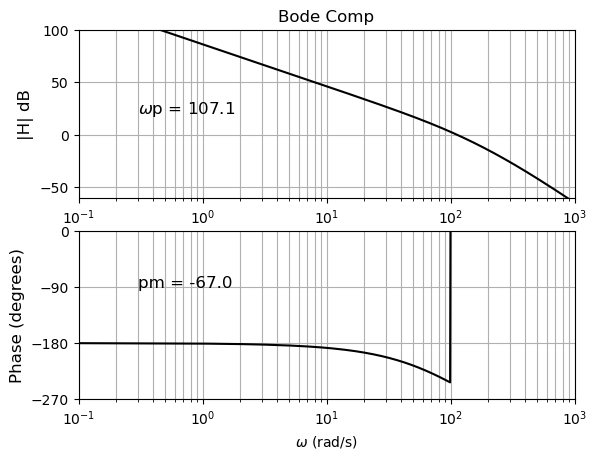

C:\Users\gjsta\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:1971: RuntimeWarning: overflow encountered in matmul
  xout[i] = xout[i-1] @ Ad + U[i-1] @ Bd0 + U[i] @ Bd1
C:\Users\gjsta\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:1971: RuntimeWarning: invalid value encountered in matmul
  xout[i] = xout[i-1] @ Ad + U[i-1] @ Bd0 + U[i] @ Bd1
C:\Users\gjsta\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:1973: RuntimeWarning: overflow encountered in matmul
  yout = squeeze(xout @ C.T) + squeeze(U @ D.T)
C:\Users\gjsta\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:1973: RuntimeWarning: invalid value encountered in matmul
  yout = squeeze(xout @ C.T) + squeeze(U @ D.T)


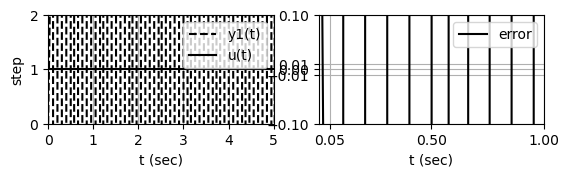

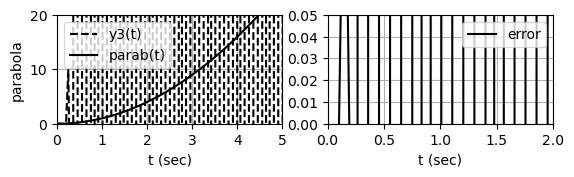

In [4]:
K = 10e5
n1 = [0, 0, 0, 1]
d1 = [1, 400, 30000, 0]

n2 = [0, 0, 0, 600]
d2 = [0, 0, 1, 0]

n12 = K*np.convolve(n1,n2)
d12 = np.convolve(d1,d2)

num = n12
den = d12

w = np.linspace(0.1,1000,num=1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(211)
plt.semilogx(w,Hmag,'k')
plt.axis([ .1, 1e3, -60, 100])
plt.ylabel('|H| dB',size = 12)
plt.text(.3,20,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
plt.title('Bode Comp')
plt.grid(which='both')

for n in range(100):
    if Hphase[n] > 0:
        Hphase[n] = Hphase[n] - 360

plt.subplot(212)
plt.semilogx(w,Hphase,'k')
plt.axis([ .1, 1e3, -270,0])
plt.yticks([-270,-180,-90,0])
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Phase (degrees)',size=12)
plt.text(.3,-90,'pm = {}'.format(round(pm,0)),fontsize=12)
plt.grid(which='both')
plt.savefig('H_bode.png',dpi=300)
plt.show()

""" Time portion """

dt = 0.05
NN = 500
TT = np.arange(0,NN*dt,dt)
step = np.zeros(NN)
ramp = np.zeros(NN)
parabola = np.zeros(NN)
errS = np.zeros(NN)
errR = np.zeros(NN)
errP = np.zeros(NN)

for i in range(NN):
    step[i] = 1.0
    ramp[i] = (dt*i)
    parabola[i] = (dt*i)**(2)
    
denCL = np.add(num,den)

t1, y1, x1 = sig.lsim((num,denCL),step,TT)
t2, y2, x2 = sig.lsim((num,denCL),ramp,TT)
t3, y3, x3 = sig.lsim((num,denCL),parabola,TT)

for i in range(NN):
    errS[i] = step[i] - y1[i]
    errR[i] = ramp[i] - y2[i]
    errP[i] = parabola[i] - y3[i]

plt.subplot(321)
plt.plot(TT,y1,'k--',label='y1(t)')
plt.plot(TT,step,'k',label='u(t)')
plt.axis([0,5,0,2])
plt.ylabel('step')
plt.xlabel('t (sec)')
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errS,'k',label='error')
plt.legend()
plt.axis([0,1,-0.1,0.1])
plt.xticks([0.05, 0.5, 1])
plt.yticks([-0.1, -0.01, 0, 0.01, 0.1])
plt.xlabel('t (sec)')
plt.grid()
plt.show()

plt.subplot(321)
plt.plot(TT,y3,'k--',label='y3(t)')
plt.plot(TT,parabola,'k',label='parab(t)')
plt.xlabel('t (sec)')
plt.ylabel('parabola')
plt.axis([0,5,0,20])
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errP,'k',label='error')
plt.xlabel('t (sec)')
plt.axis([0,2,0,0.05])
plt.yticks([0, 0.01, 0.02, 0.03, 0.04, 0.05])
plt.legend()
plt.grid()
plt.show()

In [7]:
""" Phase Lead Calculations """

p_m = 85 *(np.pi/180)
a = (1+np.sin(p_m))/(1-np.sin(p_m))
w_m = -10*np.log10(a)
print("w_m =", w_m)

w_m = -27.19813778868883


In [19]:
# Use this function to find corresponding w
center_freq = 318 #rad/s
w_guess = np.interp(center_freq, w, Hmag)
print(w_m, "=", w_guess)

-27.19813778868883 = -27.80526237884271


In [21]:
w_p = np.sqrt(a)*center_freq
w_z = center_freq/np.sqrt(a)
print("w_m =", center_freq, "rad/s")
print("w_p =", w_p, "rad/s")
print("w_z =", w_z, "rad/s")

w_m = 318 rad/s
w_p = 7283.397444401134 rad/s
w_z = 13.88417984490681 rad/s


<>:29: SyntaxWarning: invalid escape sequence '\o'
<>:41: SyntaxWarning: invalid escape sequence '\o'
<>:29: SyntaxWarning: invalid escape sequence '\o'
<>:41: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_68104\1770380588.py:29: SyntaxWarning: invalid escape sequence '\o'
  plt.text(.3,20,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
C:\Users\gjsta\AppData\Local\Temp\ipykernel_68104\1770380588.py:41: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


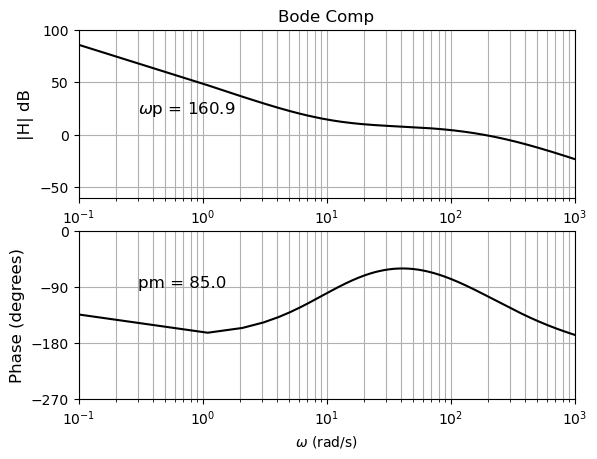

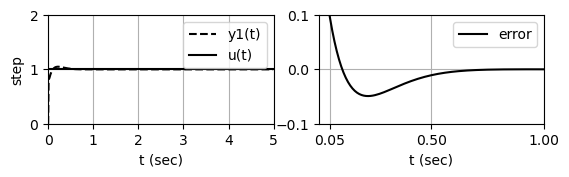

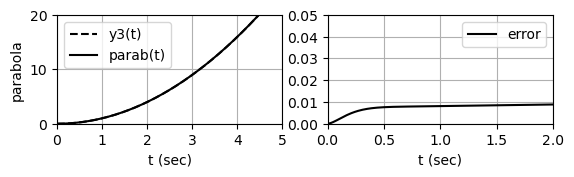

In [23]:
""" Phase Lead Implementation """

K = 10e5*(w_p/w_z)
n1 = [0, 0, 0, 1]
d1 = [1, 400, 30000, 0]

#First Gc
n2 = [0, 0, 1, 8]
d2 = [0, 0, 1, 0.1]

n12 = K*np.convolve(n1,n2)
d12 = np.convolve(d1,d2)

#Second Gc
n3 = [0, 0, 1, w_z]
d3 = [0, 0, 1, w_p]
n123 = np.convolve(n12,n3)
d123 = np.convolve(d12,d3)
num = n123
den = d123

w = np.linspace(0.1,1000,num=1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(211)
plt.semilogx(w,Hmag,'k')
plt.axis([ .1, 1e3, -60, 100])
plt.ylabel('|H| dB',size = 12)
plt.text(.3,20,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
plt.title('Bode Comp')
plt.grid(which='both')

for n in range(100):
    if Hphase[n] > 0:
        Hphase[n] = Hphase[n] - 360

plt.subplot(212)
plt.semilogx(w,Hphase,'k')
plt.axis([ .1, 1e3, -270,0])
plt.yticks([-270,-180,-90,0])
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Phase (degrees)',size=12)
plt.text(.3,-90,'pm = {}'.format(round(pm,0)),fontsize=12)
plt.grid(which='both')
plt.savefig('H_bode.png',dpi=300)
plt.show()

""" Time portion """

dt = 0.01
NN = 500
TT = np.arange(0,NN*dt,dt)
step = np.zeros(NN)
ramp = np.zeros(NN)
parabola = np.zeros(NN)
errS = np.zeros(NN)
errR = np.zeros(NN)
errP = np.zeros(NN)

for i in range(NN):
    step[i] = 1.0
    ramp[i] = (dt*i)
    parabola[i] = (dt*i)**(2)
    
denCL = np.add(num,den)

t1, y1, x1 = sig.lsim((num,denCL),step,TT)
t2, y2, x2 = sig.lsim((num,denCL),ramp,TT)
t3, y3, x3 = sig.lsim((num,denCL),parabola,TT)

for i in range(NN):
    errS[i] = step[i] - y1[i]
    errR[i] = ramp[i] - y2[i]
    errP[i] = parabola[i] - y3[i]

plt.subplot(321)
plt.plot(TT,y1,'k--',label='y1(t)')
plt.plot(TT,step,'k',label='u(t)')
plt.axis([0,5,0,2])
plt.ylabel('step')
plt.xlabel('t (sec)')
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errS,'k',label='error')
plt.legend()
plt.axis([0,1,-0.1,0.1])
plt.xticks([0.05, 0.5, 1])
plt.yticks([-0.1, 0, 0.1])
plt.xlabel('t (sec)')
plt.grid()
plt.show()

plt.subplot(321)
plt.plot(TT,y3,'k--',label='y3(t)')
plt.plot(TT,parabola,'k',label='parab(t)')
plt.xlabel('t (sec)')
plt.ylabel('parabola')
plt.axis([0,5,0,20])
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errP,'k',label='error')
plt.xlabel('t (sec)')
plt.axis([0,2,0,0.05])
plt.yticks([0, 0.01, 0.02, 0.03, 0.04, 0.05])
plt.legend()
plt.grid()
plt.show()